# Esplorazione rete e Majority Cascade

Questo notebook organizza gli esperimenti del progetto di Reti Sociali sul modello **Cost Majority Cascade**.

Gli obiettivi sono:

1. caricare e descrivere la rete `p2p-Gnutella04`;
2. definire e analizzare le funzioni costo;
3. eseguire gli esperimenti principali su \(G\), confrontando algoritmi e budget;
4. salvare risultati e tabelle in `results/data/`;
5. generare grafici in `results/plots/`;
6. eseguire stress test su \(G'\) rimuovendo archi e nodi.

## 1. Import e configurazione dei percorsi

Inizializzo le librerie, i percorsi del progetto e il seed casuale usato per garantire riproducibilità.

In [12]:
import sys
import time
from pathlib import Path

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#la root del progetto è la cartella padre.
PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

DATASET_PATH = PROJECT_ROOT / "datasets" / "p2p-Gnutella04.txt"

RESULTS_DATA_DIR = PROJECT_ROOT / "results" / "data"
RESULTS_PLOTS_DIR = PROJECT_ROOT / "results" / "plots"

RESULTS_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATASET_PATH}")
print(f"Results data dir: {RESULTS_DATA_DIR}")
print(f"Results plots dir: {RESULTS_PLOTS_DIR}")

Project root: c:\Users\faval\Desktop\Reti_sociali
Dataset path: c:\Users\faval\Desktop\Reti_sociali\datasets\p2p-Gnutella04.txt
Results data dir: c:\Users\faval\Desktop\Reti_sociali\results\data
Results plots dir: c:\Users\faval\Desktop\Reti_sociali\results\plots


## 2. Import dei moduli del progetto

Caricamento del grafo, funzioni costo, Majority Cascade, algoritmi e modifiche casuali del grafo.

In [13]:
from scripts.utils.graph_loader import load_graph

from scripts.src.cost_functions import (
    get_random_cost,
    get_degree_cost,
    get_sublinear_degree_cost,
)

from scripts.src.cascade import run_majority_cascade

from scripts.src.algorithms import (
    algorithm_1_greedy,
    algorithm_2_wtss,
    algorithm_3_threshold_deficit_greedy,
    total_cost,
)

from scripts.src.modifiers import remove_x_edges, remove_y_nodes

## 3. Caricamento del dataset

Il dataset `p2p-Gnutella04` è originariamente diretto, ma nel progetto viene trattato come grafo non orientato perché il Majority Cascade usato nelle slide della prof è definito tramite vicinato $(N(v))$, grado $(d(v))$ e soglia $\tau(v)=\left\lceil \frac{d(v)}{2} \right\rceil$.

In [14]:
G = load_graph(DATASET_PATH)

n = G.number_of_nodes()
m = G.number_of_edges()

print(f"Nodi: {n}")
print(f"Archi: {m}")
print(f"Grafo non orientato: {not G.is_directed()}")

--- Grafo caricato ---
Nodi: 10876
Archi: 39994
Nodi: 10876
Archi: 39994
Grafo non orientato: True


## 4. Analisi strutturale della rete

Statistiche utili per descrivere la rete: numero di nodi e archi, grado minimo e massimo, grado medio, densità, componenti connesse, clustering, triangoli e diametro.

In [15]:
def compute_graph_stats(G):
    degrees = dict(G.degree())
    degree_values = list(degrees.values())

    connected_components = list(nx.connected_components(G))
    giant_component_nodes = max(connected_components, key=len)
    G_giant = G.subgraph(giant_component_nodes).copy()

    stats = {
        "num_nodes": G.number_of_nodes(),
        "num_edges": G.number_of_edges(),
        "min_degree": min(degree_values),
        "max_degree": max(degree_values),
        "avg_degree": sum(degree_values) / len(degree_values),
        "density": nx.density(G),
        "num_connected_components": nx.number_connected_components(G),
        "giant_component_size": G_giant.number_of_nodes(),
        "average_clustering": nx.average_clustering(G),
        "triangles": sum(nx.triangles(G).values()) // 3,
        "diameter_giant_component": nx.diameter(G_giant),
    }

    return stats


graph_stats = compute_graph_stats(G)
graph_stats_df = pd.DataFrame([graph_stats])

graph_stats_df

,num_nodes,num_edges,min_degree,max_degree,avg_degree,density,num_connected_components,giant_component_size,average_clustering,triangles,diameter_giant_component
0,10876,39994,1,103,7.354542,0.000676,1,10876,0.006218,934,10


In [16]:
graph_stats_path = RESULTS_DATA_DIR / "graph_stats.csv"
graph_stats_df.to_csv(graph_stats_path, index=False)

print(f"Statistiche della rete salvate in: {graph_stats_path}")

Statistiche della rete salvate in: c:\Users\faval\Desktop\Reti_sociali\results\data\graph_stats.csv


### 4.1 Distribuzione dei gradi

La distribuzione dei gradi serve a mostrare quanto la rete sia sparsa e quanto siano eterogenei i nodi.

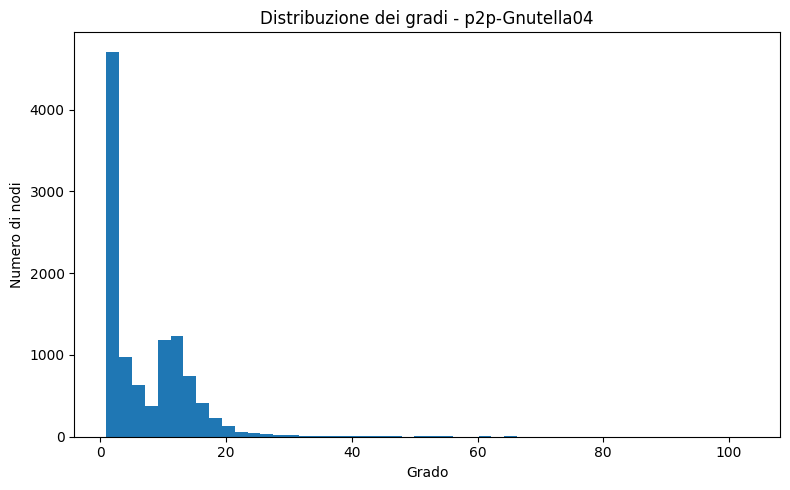

Grafico salvato in: c:\Users\faval\Desktop\Reti_sociali\results\plots\degree_distribution.png


In [17]:
degree_values = [degree for _, degree in G.degree()]

plt.figure(figsize=(8, 5))
plt.hist(degree_values, bins=50)
plt.xlabel("Grado")
plt.ylabel("Numero di nodi")
plt.title("Distribuzione dei gradi - p2p-Gnutella04")
plt.tight_layout()

degree_plot_path = RESULTS_PLOTS_DIR / "degree_distribution.png"
plt.savefig(degree_plot_path, dpi=300)
plt.show()

print(f"Grafico salvato in: {degree_plot_path}")

## 5. Definizione delle funzioni costo

Consideriamo tre funzioni costo:

1. **Random Cost**, richiesta dalle slide;
2. **Degree Cost**, richiesta dalle slide, $c(u)=\left\lceil \frac{d(u)}{2} \right\rceil$;
3. **Sublinear Degree Cost**, funzione proposta nel progetto, $c(u)=1+\left\lceil \log_2(1+d(u)) \right\rceil$.

In [18]:
random_costs = get_random_cost(G, min_c=1, max_c=10, seed=RANDOM_SEED)
degree_costs = get_degree_cost(G)
sublinear_degree_costs = get_sublinear_degree_cost(G)

cost_functions = {
    "random": random_costs,
    "degree": degree_costs,
    "sublinear": sublinear_degree_costs,
}

## 6. Analisi delle funzioni costo

Per ogni funzione costo calcoliamo minimo, massimo, media, mediana e costo totale, in questo modo i valori mi aiutano a giustificare la scelta dei budget sperimentali.

In [19]:
def summarize_costs(costs, name):
    values = list(costs.values())

    return {
        "cost_function": name,
        "min_cost": min(values),
        "max_cost": max(values),
        "avg_cost": sum(values) / len(values),
        "median_cost": float(np.median(values)),
        "total_cost": sum(values),
    }


cost_stats_df = pd.DataFrame([
    summarize_costs(costs, name)
    for name, costs in cost_functions.items()
])

cost_stats_df

,cost_function,min_cost,max_cost,avg_cost,median_cost,total_cost
0,random,1,10,5.523170,6.0,60070
1,degree,1,52,3.968922,3.0,43166
2,sublinear,2,8,3.862633,4.0,42010


In [20]:
cost_stats_path = RESULTS_DATA_DIR / "cost_stats.csv"
cost_stats_df.to_csv(cost_stats_path, index=False)

print(f"Statistiche delle funzioni costo salvate in: {cost_stats_path}")

Statistiche delle funzioni costo salvate in: c:\Users\faval\Desktop\Reti_sociali\results\data\cost_stats.csv


### 6.1 Confronto grafico delle funzioni costo

Confronto la distribuzione dei costi assegnati ai nodi dalle tre funzioni.

<Figure size 800x500 with 0 Axes>

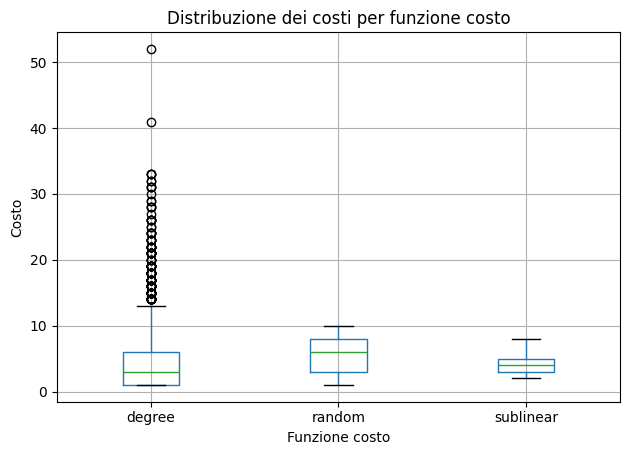

Grafico salvato in: c:\Users\faval\Desktop\Reti_sociali\results\plots\cost_functions_boxplot.png


In [21]:
cost_rows = []

for cost_name, costs in cost_functions.items():
    for node, cost in costs.items():
        cost_rows.append({
            "node": node,
            "cost_function": cost_name,
            "cost": cost,
        })

cost_values_df = pd.DataFrame(cost_rows)

plt.figure(figsize=(8, 5))
cost_values_df.boxplot(column="cost", by="cost_function")
plt.title("Distribuzione dei costi per funzione costo")
plt.suptitle("")
plt.xlabel("Funzione costo")
plt.ylabel("Costo")
plt.tight_layout()

cost_boxplot_path = RESULTS_PLOTS_DIR / "cost_functions_boxplot.png"
plt.savefig(cost_boxplot_path, dpi=300)
plt.show()

print(f"Grafico salvato in: {cost_boxplot_path}")

## 7. Definizione dei budget

Per ogni funzione costo, il budget \(k\) viene calcolato come percentuale del costo totale associato alla funzione considerata.

Le percentuali usate sono:

\[
0.5\%, 1\%, 2\%, 5\%, 10\%, 20\%
\]

In [22]:
budget_percentages = [0.005, 0.01, 0.02, 0.05, 0.10, 0.20]


def compute_budgets(costs, percentages):
    total_c = sum(costs.values())

    return {
        p: max(1, int(total_c * p))
        for p in percentages
    }


budgets_by_cost = {
    name: compute_budgets(costs, budget_percentages)
    for name, costs in cost_functions.items()
}

budgets_by_cost_df = pd.DataFrame(budgets_by_cost)
budgets_by_cost_df.index.name = "budget_percentage"
budgets_by_cost_df

,random,degree,sublinear
budget_percentage,,,
0.005,300,215,210
0.010,600,431,420
0.020,1201,863,840
0.050,3003,2158,2100
0.100,6007,4316,4201
0.200,12014,8633,8402


In [23]:
budgets_path = RESULTS_DATA_DIR / "budgets_by_cost.csv"
budgets_by_cost_df.to_csv(budgets_path)

print(f"Budget salvati in: {budgets_path}")

Budget salvati in: c:\Users\faval\Desktop\Reti_sociali\results\data\budgets_by_cost.csv


## 8. Definizione degli algoritmi

Per il confronto principale consideriamo:

1. Greedy f1;
2. Greedy f2;
3. Greedy f3;
4. WTSS;
5. Threshold-Deficit Greedy, l'euristica proposta nel progetto.

Tutte le funzioni vengono adattate alla stessa firma:

```python
algorithm_fn(G, k, costs)
```

In [24]:
ALGORITHMS = {
    "Greedy f1": lambda G, k, costs: algorithm_1_greedy(
        G, k, costs, potential_type="f1"
    ),
    "Greedy f2": lambda G, k, costs: algorithm_1_greedy(
        G, k, costs, potential_type="f2"
    ),
    "Greedy f3": lambda G, k, costs: algorithm_1_greedy(
        G, k, costs, potential_type="f3"
    ),
    "WTSS": lambda G, k, costs: algorithm_2_wtss(
        G, k, costs
    ),
    "Threshold-Deficit Greedy": lambda G, k, costs: algorithm_3_threshold_deficit_greedy(
        G, costs, k
    ),
}

list(ALGORITHMS.keys())

['Greedy f1', 'Greedy f2', 'Greedy f3', 'WTSS', 'Threshold-Deficit Greedy']

### 9. Funzione di valutazione sperimentale

Questa funzione esegue un algoritmo, ottiene il seed set $S$, verifica il rispetto del budget e poi calcola la diffusione finale tramite Majority Cascade.

La metrica principale è:

$$
\frac{|Inf[G,S]|}{|V|}
$$

Questa metrica rappresenta la frazione di nodi della rete che vengono attivati a partire dal seed set selezionato.

In [25]:
def run_single_experiment(G, algorithm_name, algorithm_fn, costs, cost_function_name, budget_percentage, k):
    """
    Esegue un singolo esperimento:
    1. selezione del seed set S;
    2. verifica del vincolo c(S) <= k;
    3. simulazione Majority Cascade;
    4. calcolo delle metriche.
    """
    start_time = time.perf_counter()

    seed_set = algorithm_fn(G, k, costs)
    seed_set_cost = total_cost(seed_set, costs)

    if seed_set_cost > k:
        raise ValueError(
            f"Budget superato: algoritmo={algorithm_name}, "
            f"costo={seed_set_cost}, budget={k}"
        )

    activated_nodes = run_majority_cascade(G, seed_set)

    end_time = time.perf_counter()

    activated_count = len(activated_nodes)

    return {
        "cost_function": cost_function_name,
        "algorithm": algorithm_name,
        "budget_percentage": budget_percentage,
        "budget_k": k,
        "seed_set_size": len(seed_set),
        "seed_set_cost": seed_set_cost,
        "activated_nodes": activated_count,
        "diffusion_ratio": activated_count / G.number_of_nodes(),
        "runtime_seconds": end_time - start_time,
        "num_nodes": G.number_of_nodes(),
        "num_edges": G.number_of_edges(),
        "total_cost": sum(costs.values()),
    }

## 10. Esperimenti principali su $G$

Eseguiamo tutte le combinazioni:

$$
3 \text{ funzioni costo} \times 5 \text{ algoritmi} \times 6 \text{ budget} = 90
$$

per un totale di 90 esecuzioni.

Per evitare di ricalcolare tutto ogni volta, se `main_results.csv` esiste già viene caricato da file. Per forzare una nuova esecuzione, impostare `FORCE_RERUN_MAIN = True`.

In [26]:
MAIN_RESULTS_PATH = RESULTS_DATA_DIR / "main_results.csv"
FORCE_RERUN_MAIN = False

if MAIN_RESULTS_PATH.exists() and not FORCE_RERUN_MAIN:
    print(f"Carico risultati esistenti da: {MAIN_RESULTS_PATH}")
    main_results_df = pd.read_csv(MAIN_RESULTS_PATH)
else:
    results = []

    for cost_name, costs in cost_functions.items():
        print(f"\nCost function: {cost_name}")

        for budget_percentage, k in budgets_by_cost[cost_name].items():
            print(f"  Budget {budget_percentage * 100:.1f}% -> k={k}")

            for algorithm_name, algorithm_fn in ALGORITHMS.items():
                print(f"    Running {algorithm_name}...")

                result = run_single_experiment(
                    G=G,
                    algorithm_name=algorithm_name,
                    algorithm_fn=algorithm_fn,
                    costs=costs,
                    cost_function_name=cost_name,
                    budget_percentage=budget_percentage,
                    k=k,
                )

                results.append(result)

                print(
                    f"      activated={result['activated_nodes']} "
                    f"ratio={result['diffusion_ratio']:.4f} "
                    f"seeds={result['seed_set_size']} "
                    f"cost={result['seed_set_cost']} "
                    f"time={result['runtime_seconds']:.2f}s"
                )

    main_results_df = pd.DataFrame(results)
    main_results_df.to_csv(MAIN_RESULTS_PATH, index=False)

main_results_df


Cost function: random
  Budget 0.5% -> k=300
    Running Greedy f1...
      activated=637 ratio=0.0586 seeds=253 cost=300 time=17.27s
    Running Greedy f2...
      activated=482 ratio=0.0443 seeds=238 cost=300 time=16.67s
    Running Greedy f3...
      activated=709 ratio=0.0652 seeds=265 cost=300 time=19.04s
    Running WTSS...
      activated=399 ratio=0.0367 seeds=145 cost=299 time=8.36s
    Running Threshold-Deficit Greedy...
      activated=857 ratio=0.0788 seeds=265 cost=300 time=3.30s
  Budget 1.0% -> k=600
    Running Greedy f1...
      activated=1172 ratio=0.1078 seeds=471 cost=598 time=36.57s
    Running Greedy f2...
      activated=937 ratio=0.0862 seeds=451 cost=599 time=33.26s
    Running Greedy f3...
      activated=1226 ratio=0.1127 seeds=477 cost=596 time=35.68s
    Running WTSS...
      activated=753 ratio=0.0692 seeds=290 cost=598 time=8.79s
    Running Threshold-Deficit Greedy...
      activated=1385 ratio=0.1273 seeds=463 cost=600 time=5.74s
  Budget 2.0% -> k=120

,cost_function,algorithm,budget_percentage,budget_k,seed_set_size,seed_set_cost,activated_nodes,diffusion_ratio,runtime_seconds,num_nodes,num_edges,total_cost
0,random,Greedy f1,0.005,300,253,300,637,0.058569,17.274628,10876,39994,60070
1,random,Greedy f2,0.005,300,238,300,482,0.044318,16.666359,10876,39994,60070
2,random,Greedy f3,0.005,300,265,300,709,0.065189,19.037550,10876,39994,60070
3,random,WTSS,0.005,300,145,299,399,0.036686,8.355975,10876,39994,60070
4,random,Threshold-Deficit Greedy,0.005,300,265,300,857,0.078797,3.302983,10876,39994,60070
...,...,...,...,...,...,...,...,...,...,...,...,...
85,sublinear,Greedy f1,0.200,8402,1498,8401,10850,0.997609,92.607093,10876,39994,42010
86,sublinear,Greedy f2,0.200,8402,1519,8402,10840,0.996690,99.985251,10876,39994,42010
87,sublinear,Greedy f3,0.200,8402,1530,8400,10871,0.999540,102.830523,10876,39994,42010
88,sublinear,WTSS,0.200,8402,878,4939,10876,1.000000,10.302280,10876,39994,42010


## 11. Controlli di correttezza sui risultati

Controllo delle condizioni per verificare la validità dei dati:

1. il costo del seed set non deve superare il budget;
2. i nodi attivati non possono superare il numero totale di nodi;
3. il diffusion ratio deve essere compreso tra 0 e 1;
4. il diffusion ratio deve coincidere con `activated_nodes / num_nodes`.

In [27]:
def validate_main_results(df):
    errors = []

    over_budget = df[df["seed_set_cost"] > df["budget_k"]]
    if not over_budget.empty:
        errors.append(f"Seed set oltre budget: {len(over_budget)} righe")

    invalid_activated = df[df["activated_nodes"] > df["num_nodes"]]
    if not invalid_activated.empty:
        errors.append(f"Nodi attivati maggiori del numero di nodi: {len(invalid_activated)} righe")

    invalid_ratio = df[(df["diffusion_ratio"] < 0) | (df["diffusion_ratio"] > 1)]
    if not invalid_ratio.empty:
        errors.append(f"Diffusion ratio fuori [0,1]: {len(invalid_ratio)} righe")

    expected_ratio = df["activated_nodes"] / df["num_nodes"]
    mismatched_ratio = df[~np.isclose(df["diffusion_ratio"], expected_ratio)]
    if not mismatched_ratio.empty:
        errors.append(f"Diffusion ratio non coerente con activated_nodes/num_nodes: {len(mismatched_ratio)} righe")

    if errors:
        raise ValueError("Controlli falliti:\n" + "\n".join(errors))

    print("Tutti i controlli sui risultati principali sono superati.")


validate_main_results(main_results_df)

Tutti i controlli sui risultati principali sono superati.


## 12. Tabelle riassuntive per funzione costo

Per ogni funzione costo genero una tabella con budget sulle righe, algoritmi sulle colonne e diffusion ratio come valore.

In [28]:
for cost_name in cost_functions.keys():
    pivot = main_results_df[main_results_df["cost_function"] == cost_name].pivot_table(
        index="budget_k",
        columns="algorithm",
        values="diffusion_ratio"
    )

    display(pivot)

    pivot_path = RESULTS_DATA_DIR / f"table_diffusion_ratio_{cost_name}.csv"
    pivot.to_csv(pivot_path)

    print(f"Tabella salvata in: {pivot_path}")

algorithm,Greedy f1,Greedy f2,Greedy f3,Threshold-Deficit Greedy,WTSS
budget_k,,,,,
300,0.058569,0.044318,0.065189,0.078797,0.036686
600,0.107760,0.086153,0.112725,0.127345,0.069235
1201,0.175156,0.148768,0.181684,0.210647,0.127345
3003,0.997609,0.997609,0.999540,1.000000,0.314638
6007,0.998529,0.997609,0.999540,1.000000,1.000000
12014,0.999540,0.999540,1.000000,1.000000,1.000000


Tabella salvata in: c:\Users\faval\Desktop\Reti_sociali\results\data\table_diffusion_ratio_random.csv


algorithm,Greedy f1,Greedy f2,Greedy f3,Threshold-Deficit Greedy,WTSS
budget_k,,,,,
215,0.002207,0.005425,0.022803,0.026296,0.018665
431,0.004597,0.011493,0.037330,0.047536,0.030618
863,0.012229,0.024458,0.064362,0.087532,0.048455
2158,0.036594,0.068683,0.133137,0.206602,0.095164
4316,0.089831,0.134241,0.232071,0.390217,0.171203
8633,0.263424,0.237312,0.410905,1.000000,1.000000


Tabella salvata in: c:\Users\faval\Desktop\Reti_sociali\results\data\table_diffusion_ratio_degree.csv


algorithm,Greedy f1,Greedy f2,Greedy f3,Threshold-Deficit Greedy,WTSS
budget_k,,,,,
210,0.009470,0.006712,0.012780,0.021239,0.014711
420,0.023722,0.011861,0.022986,0.034204,0.023906
840,0.049191,0.025009,0.047076,0.069603,0.041651
2100,0.116311,0.067028,0.114196,0.184075,0.097003
4201,0.240989,0.165042,0.276664,0.400975,0.205866
8402,0.997609,0.996690,0.999540,1.000000,1.000000


Tabella salvata in: c:\Users\faval\Desktop\Reti_sociali\results\data\table_diffusion_ratio_sublinear.csv


## 13. Grafici principali: diffusion ratio al variare del budget

Genero un grafico per ogni funzione costo. Ogni curva rappresenta un algoritmo.

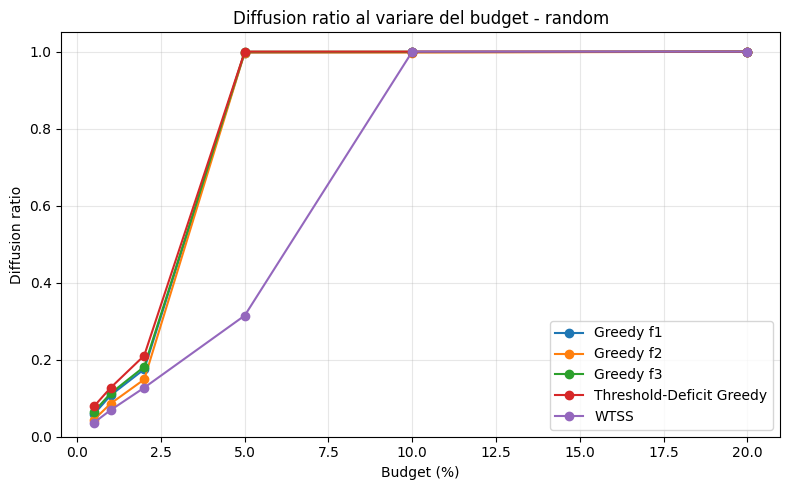

Grafico salvato in: c:\Users\faval\Desktop\Reti_sociali\results\plots\influence_vs_budget_random.png


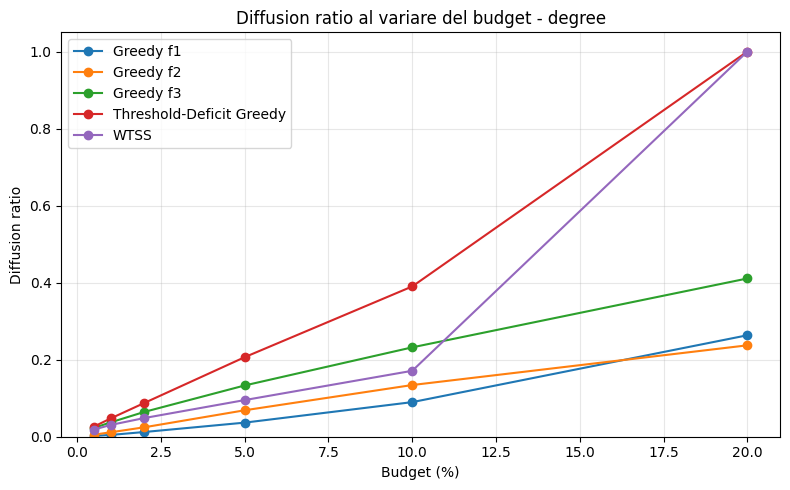

Grafico salvato in: c:\Users\faval\Desktop\Reti_sociali\results\plots\influence_vs_budget_degree.png


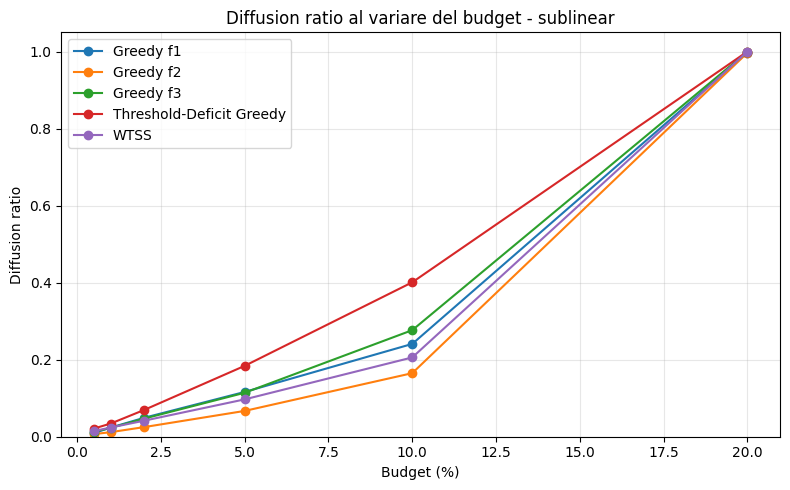

Grafico salvato in: c:\Users\faval\Desktop\Reti_sociali\results\plots\influence_vs_budget_sublinear.png


In [29]:
def plot_influence_vs_budget_all_algorithms(results_df, cost_function_name, output_path):
    subset = results_df[results_df["cost_function"] == cost_function_name].copy()

    plt.figure(figsize=(8, 5))

    for algorithm_name, group in subset.groupby("algorithm"):
        group = group.sort_values("budget_percentage")
        plt.plot(
            group["budget_percentage"] * 100,
            group["diffusion_ratio"],
            marker="o",
            label=algorithm_name,
        )

    plt.xlabel("Budget (%)")
    plt.ylabel("Diffusion ratio")
    plt.title(f"Diffusion ratio al variare del budget - {cost_function_name}")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()


for cost_name in cost_functions.keys():
    output_path = RESULTS_PLOTS_DIR / f"influence_vs_budget_{cost_name}.png"
    plot_influence_vs_budget_all_algorithms(
        results_df=main_results_df,
        cost_function_name=cost_name,
        output_path=output_path,
    )

    print(f"Grafico salvato in: {output_path}")

## 14. Analisi dei tempi di esecuzione

Questa sezione confronta i tempi medi degli algoritmi; discuto quindi il compromesso tra qualità della diffusione e costo computazionale.

In [30]:
runtime_summary_df = (
    main_results_df
    .groupby("algorithm", as_index=False)["runtime_seconds"]
    .mean()
    .sort_values("runtime_seconds", ascending=False)
)

runtime_summary_df

,algorithm,runtime_seconds
1,Greedy f2,61.428315
2,Greedy f3,55.927616
0,Greedy f1,45.425518
3,Threshold-Deficit Greedy,12.234540
4,WTSS,9.462319


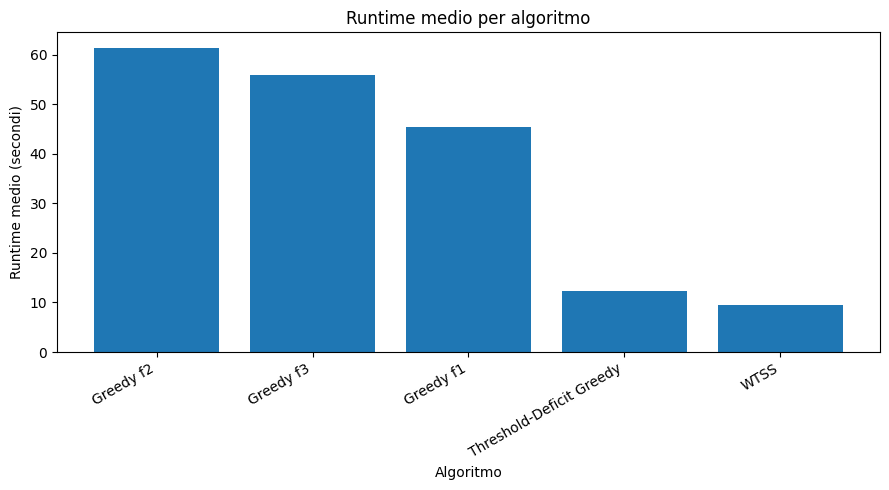

Tabella salvata in: c:\Users\faval\Desktop\Reti_sociali\results\data\runtime_summary_by_algorithm.csv
Grafico salvato in: c:\Users\faval\Desktop\Reti_sociali\results\plots\average_runtime_by_algorithm.png


In [31]:
runtime_summary_path = RESULTS_DATA_DIR / "runtime_summary_by_algorithm.csv"
runtime_summary_df.to_csv(runtime_summary_path, index=False)

plt.figure(figsize=(9, 5))
plt.bar(runtime_summary_df["algorithm"], runtime_summary_df["runtime_seconds"])
plt.xlabel("Algoritmo")
plt.ylabel("Runtime medio (secondi)")
plt.title("Runtime medio per algoritmo")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

runtime_plot_path = RESULTS_PLOTS_DIR / "average_runtime_by_algorithm.png"
plt.savefig(runtime_plot_path, dpi=300)
plt.show()

print(f"Tabella salvata in: {runtime_summary_path}")
print(f"Grafico salvato in: {runtime_plot_path}")

## 15. Selezione delle configurazioni per gli stress test

Gli stress test valutano cosa succede quando il grafo originale \(G\) viene modificato in \(G'\).

Secondo le slide:

- per la rimozione di archi si usa lo stesso seed set \(S\) calcolato su \(G\);
- per la rimozione di nodi si usa \(S'=S\cap V(G')\), perché alcuni seed possono essere rimossi.

Uso due configurazioni rappresentative:

1. `Degree Cost + Greedy f3 + budget 10%`, cioè una baseline forte già emersa dagli esperimenti;
2. `Sublinear Degree Cost + Threshold-Deficit Greedy + budget 10%`, cioè la nuova proposta del progetto.

In [32]:
stress_configs = [
    {
        "configuration": "degree_greedy_f3_10",
        "cost_function": "degree",
        "algorithm": "Greedy f3",
        "budget_percentage": 0.10,
    },
    {
        "configuration": "sublinear_threshold_deficit_10",
        "cost_function": "sublinear",
        "algorithm": "Threshold-Deficit Greedy",
        "budget_percentage": 0.10,
    },
]

stress_configs

[{'configuration': 'degree_greedy_f3_10',
  'cost_function': 'degree',
  'algorithm': 'Greedy f3',
  'budget_percentage': 0.1},
 {'configuration': 'sublinear_threshold_deficit_10',
  'cost_function': 'sublinear',
  'algorithm': 'Threshold-Deficit Greedy',
  'budget_percentage': 0.1}]

## 16. Preparazione dei seed set per gli stress test

Per ogni configurazione selezionata, ricalcolo il seed set sul grafo originale \(G\) e salvo l'influenza originale \(|Inf[G,S]|\).

In [33]:
def build_stress_seed_sets(G, stress_configs, cost_functions, budgets_by_cost, algorithms):
    prepared = []

    for cfg in stress_configs:
        cost_name = cfg["cost_function"]
        algorithm_name = cfg["algorithm"]
        budget_percentage = cfg["budget_percentage"]

        costs = cost_functions[cost_name]
        k = budgets_by_cost[cost_name][budget_percentage]
        algorithm_fn = algorithms[algorithm_name]

        seed_set = algorithm_fn(G, k, costs)
        seed_set_cost = total_cost(seed_set, costs)

        if seed_set_cost > k:
            raise ValueError(
                f"Budget superato nella configurazione {cfg['configuration']}: "
                f"costo={seed_set_cost}, budget={k}"
            )

        original_active = run_majority_cascade(G, seed_set)
        original_influence = len(original_active)

        prepared.append({
            **cfg,
            "budget_k": k,
            "seed_set": seed_set,
            "seed_set_size": len(seed_set),
            "seed_set_cost": seed_set_cost,
            "original_influence": original_influence,
            "original_ratio": original_influence / G.number_of_nodes(),
        })

    return prepared


prepared_stress_configs = build_stress_seed_sets(
    G=G,
    stress_configs=stress_configs,
    cost_functions=cost_functions,
    budgets_by_cost=budgets_by_cost,
    algorithms=ALGORITHMS,
)

pd.DataFrame([
    {k: v for k, v in cfg.items() if k != "seed_set"}
    for cfg in prepared_stress_configs
])

,configuration,cost_function,algorithm,budget_percentage,budget_k,seed_set_size,seed_set_cost,original_influence,original_ratio
0,degree_greedy_f3_10,degree,Greedy f3,0.1,4316,826,4311,2524,0.232071
1,sublinear_threshold_deficit_10,sublinear,Threshold-Deficit Greedy,0.1,4201,756,4200,4361,0.400975


## 17. Stress test: rimozione casuale di archi

Rimuovo percentuali crescenti di archi e valuto la diffusione su \(G'\) mantenendo lo stesso seed set \(S\).

In [34]:
edge_removal_percentages = [0.01, 0.05, 0.10, 0.20]


def run_edge_removal_stress_tests(G, prepared_configs, removal_percentages, random_seed=42):
    rows = []

    for cfg in prepared_configs:
        seed_set = cfg["seed_set"]

        for p in removal_percentages:
            removed_edges = int(G.number_of_edges() * p)
            G_prime = remove_x_edges(G, removed_edges, seed=random_seed)

            # Per la rimozione di archi, i nodi restano gli stessi.
            seed_set_prime = set(seed_set) & set(G_prime.nodes())

            modified_active = run_majority_cascade(G_prime, seed_set_prime)
            modified_influence = len(modified_active)

            absolute_variation = modified_influence - cfg["original_influence"]
            percentage_variation = (
                absolute_variation / cfg["original_influence"] * 100
                if cfg["original_influence"] > 0 else 0
            )

            rows.append({
                "configuration": cfg["configuration"],
                "cost_function": cfg["cost_function"],
                "algorithm": cfg["algorithm"],
                "budget_percentage": cfg["budget_percentage"],
                "budget_k": cfg["budget_k"],
                "seed_set_size": cfg["seed_set_size"],
                "seed_set_cost": cfg["seed_set_cost"],
                "removal_type": "edges",
                "removal_percentage": p,
                "removed_edges": removed_edges,
                "random_seed": random_seed,
                "original_influence": cfg["original_influence"],
                "modified_influence": modified_influence,
                "original_ratio": cfg["original_ratio"],
                "modified_ratio": modified_influence / G_prime.number_of_nodes(),
                "absolute_variation": absolute_variation,
                "percentage_variation": percentage_variation,
            })

    return pd.DataFrame(rows)


edge_results_df = run_edge_removal_stress_tests(
    G=G,
    prepared_configs=prepared_stress_configs,
    removal_percentages=edge_removal_percentages,
    random_seed=RANDOM_SEED,
)

edge_results_df

,configuration,cost_function,algorithm,budget_percentage,budget_k,seed_set_size,seed_set_cost,removal_type,removal_percentage,removed_edges,random_seed,original_influence,modified_influence,original_ratio,modified_ratio,absolute_variation,percentage_variation
0,degree_greedy_f3_10,degree,Greedy f3,0.1,4316,826,4311,edges,0.01,399,42,2524,2546,0.232071,0.234093,22,0.871632
1,degree_greedy_f3_10,degree,Greedy f3,0.1,4316,826,4311,edges,0.05,1999,42,2524,2621,0.232071,0.240989,97,3.843106
2,degree_greedy_f3_10,degree,Greedy f3,0.1,4316,826,4311,edges,0.10,3999,42,2524,2711,0.232071,0.249264,187,7.408875
3,degree_greedy_f3_10,degree,Greedy f3,0.1,4316,826,4311,edges,0.20,7998,42,2524,2945,0.232071,0.270780,421,16.679873
4,sublinear_threshold_deficit_10,sublinear,Threshold-Deficit Greedy,0.1,4201,756,4200,edges,0.01,399,42,4361,4276,0.400975,0.393159,-85,-1.949094
5,sublinear_threshold_deficit_10,sublinear,Threshold-Deficit Greedy,0.1,4201,756,4200,edges,0.05,1999,42,4361,4184,0.400975,0.384700,-177,-4.058702
6,sublinear_threshold_deficit_10,sublinear,Threshold-Deficit Greedy,0.1,4201,756,4200,edges,0.10,3999,42,4361,4144,0.400975,0.381022,-217,-4.975923
7,sublinear_threshold_deficit_10,sublinear,Threshold-Deficit Greedy,0.1,4201,756,4200,edges,0.20,7998,42,4361,4329,0.400975,0.398032,-32,-0.733777


In [35]:
edge_results_path = RESULTS_DATA_DIR / "edge_removal_results.csv"
edge_results_df.to_csv(edge_results_path, index=False)

print(f"Risultati stress test archi salvati in: {edge_results_path}")

Risultati stress test archi salvati in: c:\Users\faval\Desktop\Reti_sociali\results\data\edge_removal_results.csv


### 17.1 Grafici stress test archi

Mostro sia il numero assoluto di nodi attivati sia il diffusion ratio dopo la rimozione degli archi.

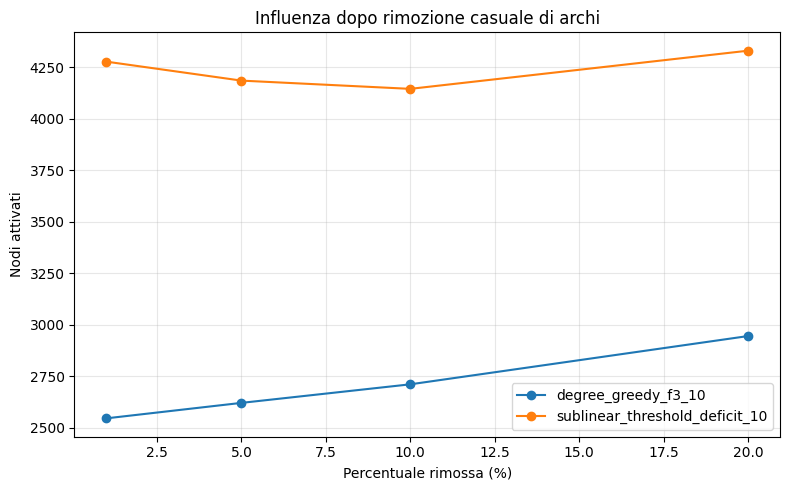

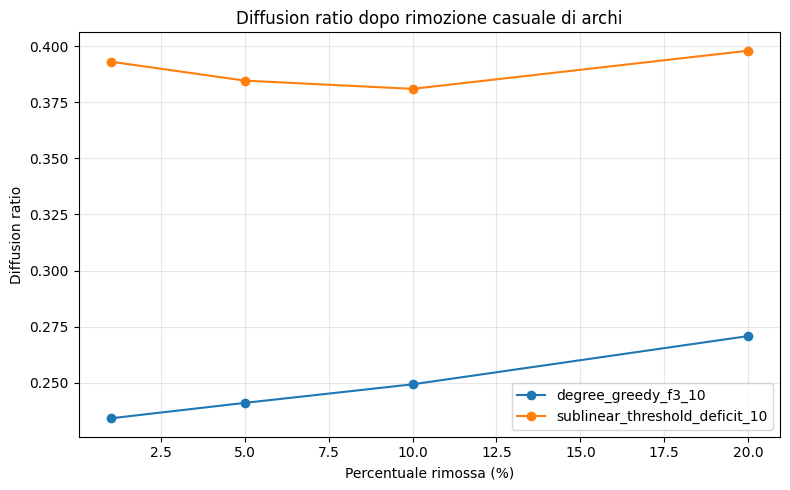

Grafici salvati in:
- c:\Users\faval\Desktop\Reti_sociali\results\plots\edge_removal_absolute_influence.png
- c:\Users\faval\Desktop\Reti_sociali\results\plots\edge_removal_diffusion_ratio.png


In [36]:
def plot_stress_results(results_df, y_column, ylabel, title, output_path):
    plt.figure(figsize=(8, 5))

    for configuration, group in results_df.groupby("configuration"):
        group = group.sort_values("removal_percentage")
        plt.plot(
            group["removal_percentage"] * 100,
            group[y_column],
            marker="o",
            label=configuration,
        )

    plt.xlabel("Percentuale rimossa (%)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()


edge_abs_plot = RESULTS_PLOTS_DIR / "edge_removal_absolute_influence.png"
plot_stress_results(
    results_df=edge_results_df,
    y_column="modified_influence",
    ylabel="Nodi attivati",
    title="Influenza dopo rimozione casuale di archi",
    output_path=edge_abs_plot,
)

edge_ratio_plot = RESULTS_PLOTS_DIR / "edge_removal_diffusion_ratio.png"
plot_stress_results(
    results_df=edge_results_df,
    y_column="modified_ratio",
    ylabel="Diffusion ratio",
    title="Diffusion ratio dopo rimozione casuale di archi",
    output_path=edge_ratio_plot,
)

print(f"Grafici salvati in:\n- {edge_abs_plot}\n- {edge_ratio_plot}")

## 18. Stress test: rimozione casuale di nodi

Rimuoviamo percentuali crescenti di nodi dal grafo originale. In questo caso il seed set deve essere aggiornato come:

$$
S' = S \cap V(G')
$$

perché alcuni seed potrebbero essere stati rimossi dal grafo. In pratica, dopo aver ottenuto il grafo modificato $G'$, si considera solo la parte del seed set ancora presente nella rete.

In [37]:
node_removal_percentages = [0.01, 0.05, 0.10, 0.20]


def run_node_removal_stress_tests(G, prepared_configs, removal_percentages, random_seed=42):
    rows = []

    for cfg in prepared_configs:
        seed_set = cfg["seed_set"]

        for p in removal_percentages:
            removed_nodes = int(G.number_of_nodes() * p)
            G_prime = remove_y_nodes(G, removed_nodes, seed=random_seed)

            seed_set_prime = set(seed_set) & set(G_prime.nodes())
            removed_seed_nodes = len(set(seed_set) - seed_set_prime)

            modified_active = run_majority_cascade(G_prime, seed_set_prime)
            modified_influence = len(modified_active)

            absolute_variation = modified_influence - cfg["original_influence"]
            percentage_variation = (
                absolute_variation / cfg["original_influence"] * 100
                if cfg["original_influence"] > 0 else 0
            )

            rows.append({
                "configuration": cfg["configuration"],
                "cost_function": cfg["cost_function"],
                "algorithm": cfg["algorithm"],
                "budget_percentage": cfg["budget_percentage"],
                "budget_k": cfg["budget_k"],
                "seed_set_size": cfg["seed_set_size"],
                "seed_set_cost": cfg["seed_set_cost"],
                "removal_type": "nodes",
                "removal_percentage": p,
                "removed_nodes": removed_nodes,
                "removed_seed_nodes": removed_seed_nodes,
                "random_seed": random_seed,
                "original_influence": cfg["original_influence"],
                "modified_influence": modified_influence,
                "original_ratio": cfg["original_ratio"],
                "modified_ratio": modified_influence / G_prime.number_of_nodes(),
                "absolute_variation": absolute_variation,
                "percentage_variation": percentage_variation,
            })

    return pd.DataFrame(rows)


node_results_df = run_node_removal_stress_tests(
    G=G,
    prepared_configs=prepared_stress_configs,
    removal_percentages=node_removal_percentages,
    random_seed=RANDOM_SEED,
)

node_results_df

,configuration,cost_function,algorithm,budget_percentage,budget_k,seed_set_size,seed_set_cost,removal_type,removal_percentage,removed_nodes,removed_seed_nodes,random_seed,original_influence,modified_influence,original_ratio,modified_ratio,absolute_variation,percentage_variation
0,degree_greedy_f3_10,degree,Greedy f3,0.1,4316,826,4311,nodes,0.01,108,3,42,2524,2539,0.232071,0.235791,15,0.594295
1,degree_greedy_f3_10,degree,Greedy f3,0.1,4316,826,4311,nodes,0.05,543,40,42,2524,2500,0.232071,0.241943,-24,-0.950872
2,degree_greedy_f3_10,degree,Greedy f3,0.1,4316,826,4311,nodes,0.10,1087,91,42,2524,2403,0.232071,0.245480,-121,-4.793978
3,degree_greedy_f3_10,degree,Greedy f3,0.1,4316,826,4311,nodes,0.20,2175,181,42,2524,2314,0.232071,0.265946,-210,-8.320127
4,sublinear_threshold_deficit_10,sublinear,Threshold-Deficit Greedy,0.1,4201,756,4200,nodes,0.01,108,11,42,4361,4172,0.400975,0.387444,-189,-4.333868
5,sublinear_threshold_deficit_10,sublinear,Threshold-Deficit Greedy,0.1,4201,756,4200,nodes,0.05,543,45,42,4361,3903,0.400975,0.377722,-458,-10.502178
6,sublinear_threshold_deficit_10,sublinear,Threshold-Deficit Greedy,0.1,4201,756,4200,nodes,0.10,1087,79,42,4361,3761,0.400975,0.384207,-600,-13.758312
7,sublinear_threshold_deficit_10,sublinear,Threshold-Deficit Greedy,0.1,4201,756,4200,nodes,0.20,2175,150,42,4361,3516,0.400975,0.404091,-845,-19.376290


In [38]:
node_results_path = RESULTS_DATA_DIR / "node_removal_results.csv"
node_results_df.to_csv(node_results_path, index=False)

print(f"Risultati stress test nodi salvati in: {node_results_path}")

Risultati stress test nodi salvati in: c:\Users\faval\Desktop\Reti_sociali\results\data\node_removal_results.csv


### 18.1 Grafici stress test nodi

Mostro il numero assoluto di nodi attivati, il diffusion ratio e il numero di seed rimossi.

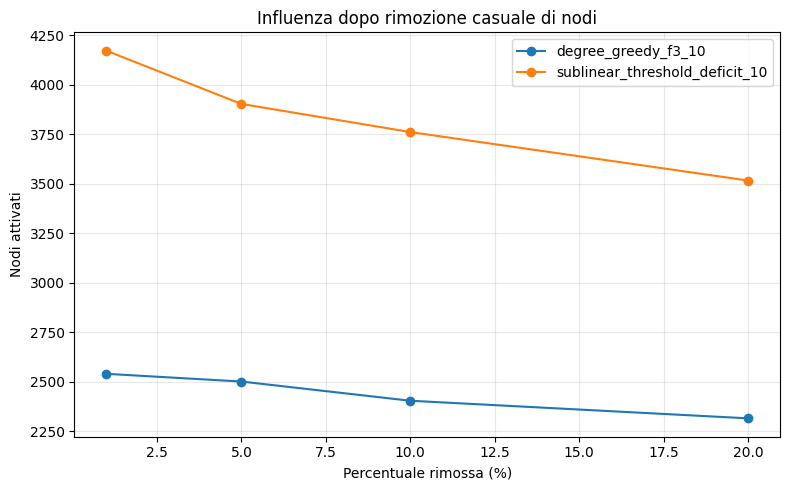

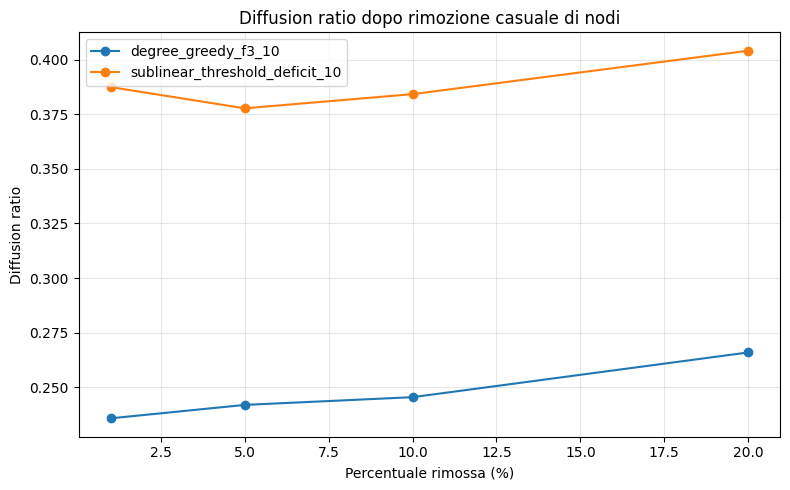

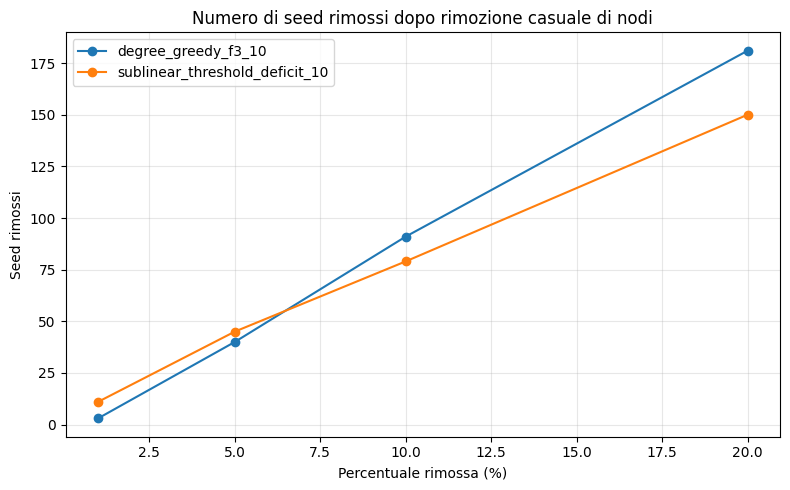

Grafici salvati in:
- c:\Users\faval\Desktop\Reti_sociali\results\plots\node_removal_absolute_influence.png
- c:\Users\faval\Desktop\Reti_sociali\results\plots\node_removal_diffusion_ratio.png
- c:\Users\faval\Desktop\Reti_sociali\results\plots\removed_seed_nodes.png


In [39]:
node_abs_plot = RESULTS_PLOTS_DIR / "node_removal_absolute_influence.png"
plot_stress_results(
    results_df=node_results_df,
    y_column="modified_influence",
    ylabel="Nodi attivati",
    title="Influenza dopo rimozione casuale di nodi",
    output_path=node_abs_plot,
)

node_ratio_plot = RESULTS_PLOTS_DIR / "node_removal_diffusion_ratio.png"
plot_stress_results(
    results_df=node_results_df,
    y_column="modified_ratio",
    ylabel="Diffusion ratio",
    title="Diffusion ratio dopo rimozione casuale di nodi",
    output_path=node_ratio_plot,
)

removed_seed_plot = RESULTS_PLOTS_DIR / "removed_seed_nodes.png"
plot_stress_results(
    results_df=node_results_df,
    y_column="removed_seed_nodes",
    ylabel="Seed rimossi",
    title="Numero di seed rimossi dopo rimozione casuale di nodi",
    output_path=removed_seed_plot,
)

print(f"Grafici salvati in:\n- {node_abs_plot}\n- {node_ratio_plot}\n- {removed_seed_plot}")

## 19. Tabelle finali per la relazione

Per ogni funzione costo e budget si individua l'algoritmo con diffusion ratio massimo. (Piu che altro mi servono per la relazione)

In [40]:
best_results_df = (
    main_results_df
    .sort_values(["cost_function", "budget_percentage", "diffusion_ratio"], ascending=[True, True, False])
    .groupby(["cost_function", "budget_percentage"], as_index=False)
    .first()
)

best_results_df[[
    "cost_function",
    "budget_percentage",
    "budget_k",
    "algorithm",
    "activated_nodes",
    "diffusion_ratio",
    "runtime_seconds",
]]

,cost_function,budget_percentage,budget_k,algorithm,activated_nodes,diffusion_ratio,runtime_seconds
0,degree,0.005,215,Threshold-Deficit Greedy,286,0.026296,2.496833
1,degree,0.010,431,Threshold-Deficit Greedy,517,0.047536,4.557106
2,degree,0.020,863,Threshold-Deficit Greedy,952,0.087532,9.847503
3,degree,0.050,2158,Threshold-Deficit Greedy,2247,0.206602,24.524714
4,degree,0.100,4316,Threshold-Deficit Greedy,4244,0.390217,45.048156
5,degree,0.200,8633,WTSS,10876,1.000000,10.095613
6,random,0.005,300,Threshold-Deficit Greedy,857,0.078797,3.302983
7,random,0.010,600,Threshold-Deficit Greedy,1385,0.127345,5.739157
8,random,0.020,1201,Threshold-Deficit Greedy,2291,0.210647,8.405937
9,random,0.050,3003,Threshold-Deficit Greedy,10876,1.000000,12.119601


In [41]:
best_results_path = RESULTS_DATA_DIR / "best_results_by_cost_and_budget.csv"
best_results_df.to_csv(best_results_path, index=False)

print(f"Tabella migliori risultati salvata in: {best_results_path}")

Tabella migliori risultati salvata in: c:\Users\faval\Desktop\Reti_sociali\results\data\best_results_by_cost_and_budget.csv
